Global Otsu Threshold: 115.0
Applying Local Otsu with blockSize=35...


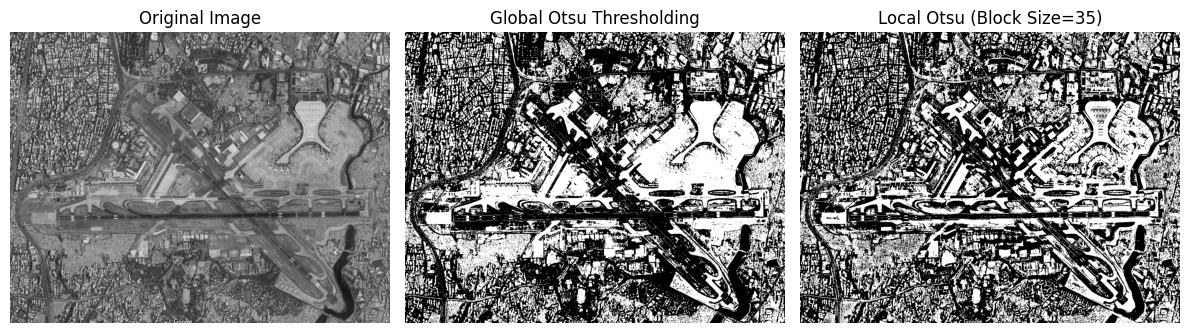

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def calculate_local_otsu_threshold(image_block):
    """
    Calculates the optimal threshold for a small image block using Otsu's method.
    """
    pixels = image_block.flatten()
    hist, _ = np.histogram(pixels, bins=256, range=[0, 256])
    total_pixels = pixels.size

    if total_pixels == 0 or np.all(pixels == pixels[0]):
         return 127

    prob = hist / total_pixels
    max_variance = 0
    optimal_threshold = 0
    cum_prob = np.cumsum(prob)
    cum_mean = np.cumsum(prob * np.arange(256))

    for t in range(256):
        prob0 = cum_prob[t]
        prob1 = 1.0 - prob0

        if prob0 == 0 or prob1 == 0:
            continue

        mean0 = cum_mean[t] / prob0 if prob0 > 0 else 0
        mean1 = (cum_mean[255] - cum_mean[t]) / prob1 if prob1 > 0 else 0
        between_class_variance = prob0 * prob1 * (mean0 - mean1) ** 2

        if between_class_variance > max_variance:
            max_variance = between_class_variance
            optimal_threshold = t

    return optimal_threshold

def apply_local_otsu_thresholding(image_path, blockSize):
    """
    Applies adaptive thresholding using local Otsu method.

    Args:
        image_path (str): Path to the input grayscale image.
        blockSize (int): Size of the square neighborhood (must be odd).

    Returns:
        numpy.ndarray: The resulting binary image.
    """
    gray_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if gray_image is None:
        print(f"Error: Could not load image from {image_path}")
        return None

    if blockSize % 2 == 0 or blockSize < 3:
        print("Error: blockSize must be an odd number and at least 3.")
        return None

    height, width = gray_image.shape
    binary_output = np.zeros_like(gray_image)
    half_block = blockSize // 2

    for i in range(height):
        for j in range(width):
            row_start = max(0, i - half_block)
            row_end = min(height, i + half_block + 1)
            col_start = max(0, j - half_block)
            col_end = min(width, j + half_block + 1)

            local_block = gray_image[row_start:row_end, col_start:col_end]
            local_threshold = calculate_local_otsu_threshold(local_block)

            if gray_image[i, j] > local_threshold:
                binary_output[i, j] = 255
            else:
                binary_output[i, j] = 0

    return binary_output

# --- Example Usage ---
if __name__ == "__main__":
    image_file = "images/image2.png"

    img_gray = cv2.imread(image_file, cv2.IMREAD_GRAYSCALE)
    if img_gray is not None:
        global_otsu_threshold, global_binary = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        print(f"Global Otsu Threshold: {global_otsu_threshold}")

        block_size = 35
        print(f"Applying Local Otsu with blockSize={block_size}...")
        local_otsu_binary = apply_local_otsu_thresholding(image_file, block_size)

        if local_otsu_binary is not None:
            # Display images using matplotlib
            plt.figure(figsize=(12, 6))
            plt.subplot(1, 3, 1)
            plt.title("Original Image")
            plt.imshow(img_gray, cmap='gray')
            plt.axis('off')

            plt.subplot(1, 3, 2)
            plt.title("Global Otsu Thresholding")
            plt.imshow(global_binary, cmap='gray')
            plt.axis('off')

            plt.subplot(1, 3, 3)
            plt.title(f"Local Otsu (Block Size={block_size})")
            plt.imshow(local_otsu_binary, cmap='gray')
            plt.axis('off')

            plt.tight_layout()
            plt.show()
    else:
         print("Could not load image for global comparison.")
